In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold

In [2]:
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').squeeze()

print(f'Features: {X_train.shape[1]}  |  Samples: {X_train.shape[0]}')

Features: 131  |  Samples: 55989


The training set has **131 raw features** across ~56K patients. The high feature count comes from one-hot encoding of categorical variables like diagnoses, medications, and discharge codes — many of these will be redundant or near-constant and will be filtered in the next step.

### Remove Near-Zero Variance Features

In [3]:
# Drop columns where >99% of values are identical — they carry no signal
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)

kept_mask = selector.get_support()
dropped = X_train.columns[~kept_mask].tolist()

X_train = X_train.loc[:, kept_mask]

print(f'Dropped {len(dropped)} near-zero variance columns')
print(f'Remaining features: {X_train.shape[1]}')

Dropped 45 near-zero variance columns
Remaining features: 86


45 of the original 131 features were nearly constant across all patients — mostly rare medication or procedure flags that are almost always 0. These carry no predictive signal and are dropped, leaving **86 features** for importance ranking.

In [4]:
# Random Forest is well-suited for importance ranking on mixed feature types.
# class_weight='balanced' accounts for the imbalanced target.
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

importance_df = (
    pd.DataFrame({'feature': X_train.columns, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

importance_df.head(20)

,feature,importance
0,number_inpatient,0.102889
1,time_in_hospital,0.074186
2,discharge_disposition_id_22,0.072809
3,num_medications,0.062271
4,num_lab_procedures,0.058453
5,age,0.057318
6,discharge_disposition_id_3,0.048980
7,number_diagnoses,0.041832
8,num_procedures,0.024460
9,discharge_disposition_id_5,0.024421


The importance score (Mean Decrease in Impurity) measures how much each feature reduces uncertainty across all splits in the forest — higher means more useful. number_inpatient alone accounts for ~10% of total importance, suggesting prior hospitalization history is the strongest single signal for 30-day readmission.

## 4. Plot Top 20 Features

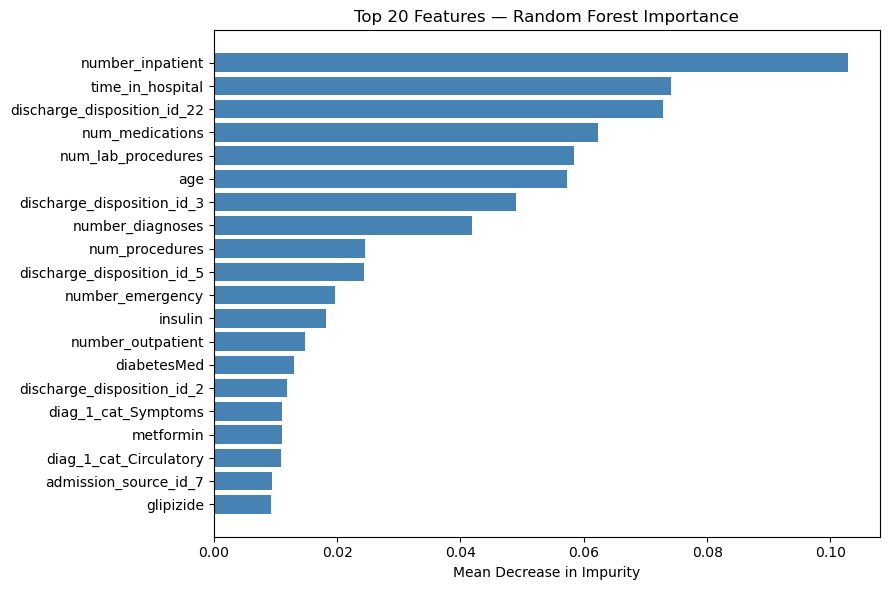

In [8]:
top20 = importance_df.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Top 20 Features — Random Forest Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

`number_inpatient` is the dominant predictor by a clear margin — patients with many prior inpatient visits are far more likely to be readmitted. Most of the top features are **utilization-based** (visits, medications, procedures, time in hospital), with a few discharge disposition codes indicating where the patient was sent after leaving.

In [6]:
# Keep features that cumulatively explain 80% of total importance.
importance_df['cumulative'] = importance_df['importance'].cumsum() / importance_df['importance'].sum()
top_features = importance_df[importance_df['cumulative'] <= 0.80]['feature'].tolist()

# Always include at least the top 15 even if cumulative threshold is hit sooner
if len(top_features) < 15:
    top_features = importance_df.head(15)['feature'].tolist()


print(top_features)


pd.Series(top_features).to_csv('top_features.csv', index=False, header=False)

['number_inpatient', 'time_in_hospital', 'discharge_disposition_id_22', 'num_medications', 'num_lab_procedures', 'age', 'discharge_disposition_id_3', 'number_diagnoses', 'num_procedures', 'discharge_disposition_id_5', 'number_emergency', 'insulin', 'number_outpatient', 'diabetesMed', 'discharge_disposition_id_2', 'diag_1_cat_Symptoms', 'metformin', 'diag_1_cat_Circulatory', 'admission_source_id_7', 'glipizide', 'race_Caucasian', 'admission_type_id_3', 'gender_Male', 'admission_type_id_2', 'diag_1_cat_Musculoskeletal', 'change', 'diag_2_cat_Neoplasm', 'diag_3_cat_Circulatory', 'discharge_disposition_id_6', 'diag_3_cat_Endocrine', 'glyburide', 'A1Cresult_None', 'diag_2_cat_Endocrine', 'diag_2_cat_Circulatory']


**34 features** were selected, these collectively explain 80% of the Random Forest's predictive power. The list is saved to top_features.csv and shared with the Logistic Regression and SVM notebook, which has no built-in feature selection of its own.